# Stock forecast review

Reads `data/stocks/forecast/<TICKER>_STOCK_PRICES.csv` — one file per ticker, written by `pipelines/stock_forecast_pipeline.py`. Each file holds **both** the historical prices and the Chronos forecast, distinguished by the `record_type` column (`"history"` / `"forecast"`).

Run `pangolin run stock_forecast_pipeline` at least once before running this notebook (from the project root, with the virtualenv from `requirements.txt` active).

In [1]:
import os
from pathlib import Path

# pangolin resolves config/data_structure.yaml and .env relative to the
# current working directory (BASEPATH defaults to "."), but Jupyter starts
# notebooks with cwd = notebooks/ — move up to the project root first.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
print(f"Working directory: {Path.cwd()}")

Working directory: c:\Users\GalluzziLorenzo\OneDrive - XTEL\Desktop\RobaLore\Repositories\pangolin-example


In [2]:
import polars as pl
import matplotlib.pyplot as plt

from pangolin.engine.DataFacility import get_project_data
from pangolin.config.settings import get_settings

D = get_project_data()
S = get_settings()

forecast_files = sorted(D.stocks.forecast.list("*_STOCK_PRICES.csv"))
print(f"Found {len(forecast_files)} file(s) in {D.stocks.forecast.path}")
forecast_files

Found 3 file(s) in C:/Users/GalluzziLorenzo/OneDrive - XTEL/Desktop/RobaLore/Repositories/pangolin-example/data/stocks/forecast


['C:/Users/GalluzziLorenzo/OneDrive - XTEL/Desktop/RobaLore/Repositories/pangolin-example/data/stocks/forecast/AAPL_STOCK_PRICES.csv',
 'C:/Users/GalluzziLorenzo/OneDrive - XTEL/Desktop/RobaLore/Repositories/pangolin-example/data/stocks/forecast/AMZN_STOCK_PRICES.csv',
 'C:/Users/GalluzziLorenzo/OneDrive - XTEL/Desktop/RobaLore/Repositories/pangolin-example/data/stocks/forecast/MSFT_STOCK_PRICES.csv']

In [3]:
# Load every ticker's file into one combined DataFrame.
frames = [
    pl.read_csv(f, separator=S.CSV_DELIMITER, try_parse_dates=True)
    for f in forecast_files
]
all_data = pl.concat(frames, how="vertical") if frames else pl.DataFrame()
all_data.sort(["ticker", "date"])

ticker,date,open,high,low,close,volume,record_type,forecast_low,forecast_high
str,date,f64,f64,f64,f64,i64,str,str,str
"""AAPL""",2024-09-03,226.654,227.100264,219.335219,220.921951,50190600,"""history""",null,null
"""AAPL""",2024-09-04,219.821161,219.940161,215.67583,219.017883,43840200,"""history""",null,null
"""AAPL""",2024-09-05,219.791409,223.609461,219.682321,220.535187,36615400,"""history""",null,null
"""AAPL""",2024-09-06,222.092153,223.371459,217.946836,218.988129,48423000,"""history""",null,null
"""AAPL""",2024-09-09,218.988112,219.434376,214.912208,219.077362,67180000,"""history""",null,null
…,…,…,…,…,…,…,…,…,…
"""MSFT""",2026-09-16,null,null,null,493.020203,null,"""forecast""","""473.36387023925784""","""515.89873046875"""
"""MSFT""",2026-09-17,null,null,null,489.797668,null,"""forecast""","""476.58605041503904""","""525.2437133789062"""
"""MSFT""",2026-09-18,null,null,null,489.797852,null,"""forecast""","""475.9415802001953""","""519.1212280273437"""


## Row counts per ticker, by record_type

In [4]:
(
    all_data
    .group_by(["ticker", "record_type"])
    .agg(pl.len().alias("rows"), pl.col("date").min().alias("from"), pl.col("date").max().alias("to"))
    .sort(["ticker", "record_type"])
)

ticker,record_type,rows,from,to
str,str,u32,date,date
"""AAPL""","""forecast""",14,2026-09-03,2026-09-22
"""AAPL""","""history""",502,2024-09-03,2026-09-02
"""AMZN""","""forecast""",14,2026-09-03,2026-09-22
"""AMZN""","""history""",502,2024-09-03,2026-09-02
"""MSFT""","""forecast""",14,2026-09-03,2026-09-22
"""MSFT""","""history""",502,2024-09-03,2026-09-02


## History vs. forecast, per ticker

Solid line = actual close price. Dashed line = Chronos forecast median. Shaded band = 10th–90th percentile forecast interval (`forecast_low` / `forecast_high`).

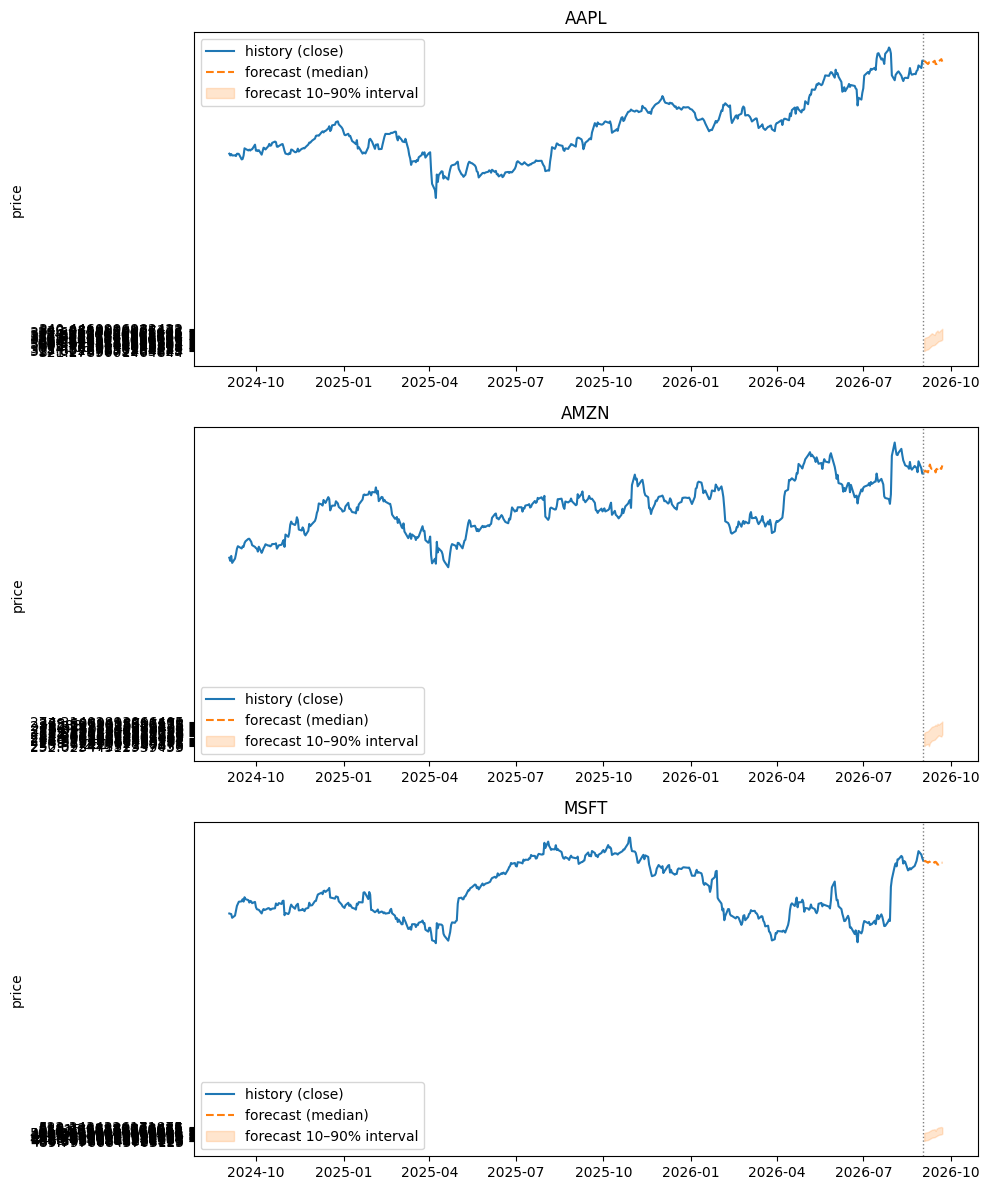

In [5]:
tickers = all_data["ticker"].unique().sort().to_list()

fig, axes = plt.subplots(len(tickers), 1, figsize=(10, 4 * len(tickers)), squeeze=False)

for ax, ticker in zip(axes[:, 0], tickers):
    df = all_data.filter(pl.col("ticker") == ticker).sort("date")
    history = df.filter(pl.col("record_type") == "history")
    forecast = df.filter(pl.col("record_type") == "forecast")

    ax.plot(history["date"], history["close"], label="history (close)", color="tab:blue")
    if len(forecast) > 0:
        ax.plot(forecast["date"], forecast["close"], "--", label="forecast (median)", color="tab:orange")
        ax.fill_between(
            forecast["date"], forecast["forecast_low"], forecast["forecast_high"],
            color="tab:orange", alpha=0.2, label="forecast 10–90% interval",
        )
        ax.axvline(history["date"].max(), color="gray", linestyle=":", linewidth=1)

    ax.set_title(ticker)
    ax.set_ylabel("price")
    ax.legend()

fig.tight_layout()
plt.show()

## Last close vs. forecast horizon end

In [6]:
rows = []
for ticker in tickers:
    df = all_data.filter(pl.col("ticker") == ticker).sort("date")
    last_history = df.filter(pl.col("record_type") == "history").tail(1)
    last_forecast = df.filter(pl.col("record_type") == "forecast").tail(1)
    if len(last_history) == 0 or len(last_forecast) == 0:
        continue
    last_close = last_history["close"][0]
    horizon_close = last_forecast["close"][0]
    rows.append({
        "ticker": ticker,
        "last_actual_date": last_history["date"][0],
        "last_actual_close": last_close,
        "forecast_horizon_date": last_forecast["date"][0],
        "forecast_horizon_close": horizon_close,
        "change_pct": round(100 * (horizon_close - last_close) / last_close, 2),
    })

pl.DataFrame(rows)

ticker,last_actual_date,last_actual_close,forecast_horizon_date,forecast_horizon_close,change_pct
str,date,f64,date,f64,f64
"""AAPL""",2026-09-02,324.959991,2026-09-22,324.01712,-0.29
"""AMZN""",2026-09-02,254.979996,2026-09-22,262.571808,2.98
"""MSFT""",2026-09-02,496.820007,2026-09-22,493.02002,-0.76
